# Timepoints bl 12m 24m

In [8]:
from pathlib import Path

import pandas as pd

# --- config ---
INPUT_PATH = Path("csvs/adnimerged.csv")
OUTPUT_PATH = Path("csvs/adnimerged_longitudinal.csv")

BASELINE_VISITS = {"sc", "bl"}
FOLLOWUP_VISITS = ["m12", "m24"]#, "m36", "m48"]
CANONICAL_VISITS = BASELINE_VISITS | set(FOLLOWUP_VISITS)
MIN_IMAGES_PER_SET = 3
TARGET_GROUPS = ["CN", "sMCI", "pMCI", "AD"]


def visit_slot(visit: str) -> str:
    return "baseline" if visit in BASELINE_VISITS else visit


def assign_group(patient_df: pd.DataFrame):
    """GROUP definido só pelas visitas canônicas (sc/bl + m12 + m24)."""
    g = patient_df[patient_df["VISIT"].isin(CANONICAL_VISITS)].sort_values(
        ["MRI_DATE", "ID_IMG"]
    )
    if g.empty:
        return pd.NA

    diags = set(g["DIAG"])

    if diags == {"CN"}:
        return "CN"
    if diags == {"AD"}:
        return "AD"
    if diags == {"MCI"}:
        return "sMCI"
    if "MCI" in diags and "AD" in diags:
        return "pMCI"
    return pd.NA


def patient_has_all_required_visits(visit_set: set[str]) -> bool:
    return bool(visit_set & BASELINE_VISITS) and set(FOLLOWUP_VISITS).issubset(visit_set)


def one_image_per_slot(df: pd.DataFrame) -> pd.DataFrame:
    out = df[df["VISIT"].isin(CANONICAL_VISITS)].copy()
    out["slot"] = out["VISIT"].map(visit_slot)
    out = out.sort_values(["ID_PT", "slot", "MRI_DATE", "ID_IMG"])
    return out.drop_duplicates(["ID_PT", "slot"], keep="first")


def build_longitudinal_sets(
    df: pd.DataFrame,
    *,
    require_all_visits: bool,
    min_images: int = MIN_IMAGES_PER_SET,
) -> tuple[pd.DataFrame, pd.Series]:
    per_slot = one_image_per_slot(df)
    slots_per_pt = per_slot.groupby("ID_PT").size()
    visits_per_pt = df.groupby("ID_PT")["VISIT"].apply(set)

    eligible = slots_per_pt.index
    if require_all_visits:
        eligible = visits_per_pt[visits_per_pt.apply(patient_has_all_required_visits)].index
    else:
        has_baseline = per_slot.loc[per_slot["slot"] == "baseline", "ID_PT"].unique()
        eligible = pd.Index(has_baseline)

    eligible = eligible[slots_per_pt.reindex(eligible).fillna(0) >= min_images]
    longitudinal = per_slot[per_slot["ID_PT"].isin(eligible)].copy()
    longitudinal = longitudinal.sort_values(["ID_PT", "MRI_DATE", "ID_IMG"])
    return longitudinal, slots_per_pt.reindex(eligible)


# --- 1) leitura e remoção de repeats ---
raw = pd.read_csv(INPUT_PATH)
raw["MRI_DATE"] = pd.to_datetime(raw["MRI_DATE"], errors="coerce")

is_repeat = raw["DESCRIPTION"].str.contains("repeat", case=False, na=False)
df = raw.loc[~is_repeat].copy()

print(f"Linhas originais: {len(raw)} | removidas (repeat): {is_repeat.sum()} | restantes: {len(df)}")

# --- 2) GROUP por paciente (apenas visitas canônicas, sem repeat) ---
group_by_pt = df.groupby("ID_PT").apply(assign_group, include_groups=False)

print("\nPacientes por GROUP (visitas canônicas sc/bl + m12 + m24):")
print(group_by_pt.value_counts(dropna=False).sort_index())

# --- 3) coorte estrita: paciente com sc/bl + m12 + m24 + m36 + m48 ---
visits_by_pt = df.groupby("ID_PT")["VISIT"].apply(set)
strict_pts = visits_by_pt[visits_by_pt.apply(patient_has_all_required_visits)].index

longitudinal, _ = build_longitudinal_sets(
    df, require_all_visits=False, min_images=MIN_IMAGES_PER_SET
)
longitudinal["GROUP"] = longitudinal["ID_PT"].map(group_by_pt)
longitudinal = longitudinal[longitudinal["GROUP"].isin(TARGET_GROUPS)].copy()

df_flex = df[df["ID_PT"].isin(longitudinal["ID_PT"].unique())].copy()

# --- 5) salvar ---

longitudinal.to_csv(OUTPUT_PATH, index=False)
print(f"Salvo flexível: {OUTPUT_PATH} ({len(longitudinal)} linhas)")

display(longitudinal.groupby(["GROUP", "slot"]).size().unstack(fill_value=0))

Linhas originais: 12921 | removidas (repeat): 3757 | restantes: 9164

Pacientes por GROUP (visitas canônicas sc/bl + m12 + m24):
AD      165
CN      184
pMCI     99
sMCI    230
<NA>    625
Name: count, dtype: int64
Salvo flexível: csvs/adnimerged_longitudinal.csv (1221 linhas)


slot,baseline,m12,m24
GROUP,,,
AD,83,83,83
CN,136,136,136
pMCI,81,81,81
sMCI,107,107,107


In [9]:
ROW_ORDER = ["CN", "sMCI", "pMCI", "AD", "All"]
COL_ORDER = ["F", "M", "All"]

pacientes = longitudinal.drop_duplicates("ID_PT")

tabela_pacientes = (
    pd.crosstab(pacientes["GROUP"], pacientes["SEX"], margins=True)
    .reindex(index=ROW_ORDER, columns=COL_ORDER)
    .astype(int)
)

tabela_imagens = (
    pd.crosstab(longitudinal["GROUP"], longitudinal["SEX"], margins=True)
    .reindex(index=ROW_ORDER, columns=COL_ORDER)
    .astype(int)
)

# mantém tabela agregada (sem SEX) para o gráfico da célula seguinte
img_por_timepoint = (
    longitudinal.groupby(["GROUP", "slot"])["ID_IMG"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["baseline", "m12", "m24"])
)

print("Pacientes (ID_PT) por GROUP × SEX:")
display(tabela_pacientes)

print("\nImagens (ID_IMG) por GROUP × SEX:")
display(tabela_imagens)

Pacientes (ID_PT) por GROUP × SEX:


SEX,F,M,All
GROUP,,,
CN,72,64,136
sMCI,38,69,107
pMCI,33,48,81
AD,41,42,83
All,184,223,407



Imagens (ID_IMG) por GROUP × SEX:


SEX,F,M,All
GROUP,,,
CN,216,192,408
sMCI,114,207,321
pMCI,99,144,243
AD,123,126,249
All,552,669,1221


In [10]:
DAYS_PER_MONTH = 30.4375
SLOT_ORDER = ["baseline", "m12", "m24"]


def mean_std(series: pd.Series) -> str:
    m = series.mean()
    s = series.std()
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.2f} ± —"
    return f"{m:.2f} ± {s:.2f}"


interval_cols = [
    "baseline→m12 (meses)",
    "m12→m24 (meses)",
    "baseline→m24 (meses)",
]

dates_by_pt = (
    longitudinal.pivot_table(
        index=["ID_PT", "GROUP"], columns="slot", values="MRI_DATE", aggfunc="first"
    )
    .reindex(columns=SLOT_ORDER)
)

dates_by_pt["bl_m12_m"] = (
    (dates_by_pt["m12"] - dates_by_pt["baseline"]).dt.days / DAYS_PER_MONTH
)
dates_by_pt["m12_m24_m"] = (
    (dates_by_pt["m24"] - dates_by_pt["m12"]).dt.days / DAYS_PER_MONTH
)
dates_by_pt["bl_m24_m"] = (
    (dates_by_pt["m24"] - dates_by_pt["baseline"]).dt.days / DAYS_PER_MONTH
)

interval_data = {}
for group in [*TARGET_GROUPS, "All"]:
    sub = dates_by_pt if group == "All" else dates_by_pt.xs(group, level="GROUP")
    interval_data[group] = {
        interval_cols[0]: mean_std(sub["bl_m12_m"]),
        interval_cols[1]: mean_std(sub["m12_m24_m"]),
        interval_cols[2]: mean_std(sub["bl_m24_m"]),
    }

tabela_intervalos = pd.DataFrame(interval_data).T.reindex([*TARGET_GROUPS, "All"])

print("Intervalo médio entre imagens (mean ± SD, em meses) — baseline / m12 / m24:")
display(tabela_intervalos)


Intervalo médio entre imagens (mean ± SD, em meses) — baseline / m12 / m24:


,baseline→m12 (meses),m12→m24 (meses),baseline→m24 (meses)
CN,12.96 ± 0.91,12.14 ± 1.06,25.10 ± 1.16
sMCI,12.88 ± 0.67,12.10 ± 0.84,24.98 ± 0.76
pMCI,12.77 ± 0.71,12.25 ± 1.13,25.03 ± 1.18
AD,12.86 ± 0.73,12.21 ± 1.49,25.07 ± 1.62
All,12.88 ± 0.78,12.17 ± 1.12,25.05 ± 1.19


In [11]:
# DAYS_PER_MONTH = 30.4375


# def mean_std(series: pd.Series) -> str:
#     m = series.mean()
#     s = series.std()
#     if pd.isna(m):
#         return ""
#     if pd.isna(s):
#         return f"{m:.2f} ± —"
#     return f"{m:.2f} ± {s:.2f}"


# interval_cols = ["t0→t1 (meses)", "t1→t2 (meses)", "t0→t2 (meses)"]

# dates_by_pt = (
#     longitudinal.pivot_table(
#         index=["ID_PT", "GROUP"], columns="slot", values="MRI_DATE", aggfunc="first"
#     )
#     .reindex(columns=SLOT_LABELS)
# )

# dates_by_pt["t0_t1_m"] = (dates_by_pt["t1"] - dates_by_pt["t0"]).dt.days / DAYS_PER_MONTH
# dates_by_pt["t1_t2_m"] = (dates_by_pt["t2"] - dates_by_pt["t1"]).dt.days / DAYS_PER_MONTH
# dates_by_pt["t0_t2_m"] = (dates_by_pt["t2"] - dates_by_pt["t0"]).dt.days / DAYS_PER_MONTH

# interval_data = {}
# for group in [*TARGET_GROUPS, "All"]:
#     sub = dates_by_pt if group == "All" else dates_by_pt.xs(group, level="GROUP")
#     interval_data[group] = {
#         interval_cols[0]: mean_std(sub["t0_t1_m"]),
#         interval_cols[1]: mean_std(sub["t1_t2_m"]),
#         interval_cols[2]: mean_std(sub["t0_t2_m"]),
#     }

# tabela_intervalos = pd.DataFrame(interval_data).T.reindex([*TARGET_GROUPS, "All"])

# print("Intervalo médio entre imagens (mean ± SD, em meses):")
# display(tabela_intervalos)


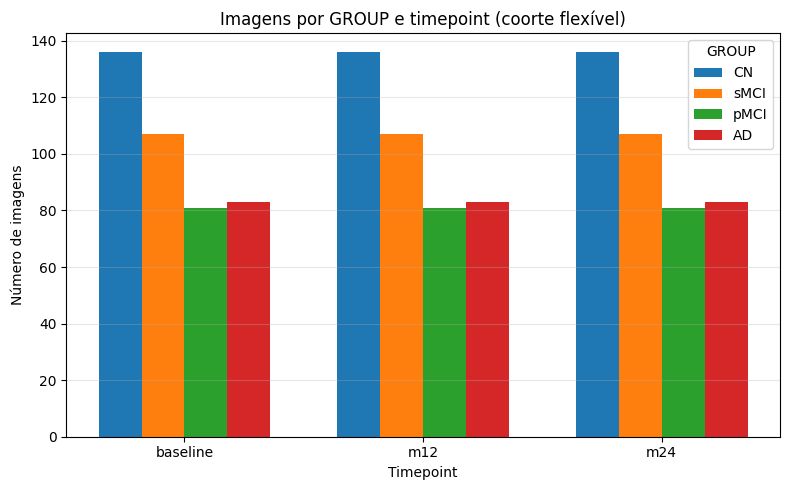

In [12]:
import matplotlib.pyplot as plt

plot_df = img_por_timepoint.reindex(TARGET_GROUPS)
x = plot_df.columns.tolist()
width = 0.18
groups = plot_df.index.tolist()
offsets = [(i - (len(groups) - 1) / 2) * width for i in range(len(groups))]

fig, ax = plt.subplots(figsize=(8, 5))
for offset, group in zip(offsets, groups):
    ax.bar(
        [i + offset for i in range(len(x))],
        plot_df.loc[group].values,
        width=width,
        label=group,
    )

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x)
ax.set_xlabel("Timepoint")
ax.set_ylabel("Número de imagens")
ax.set_title("Imagens por GROUP e timepoint (coorte flexível)")
ax.legend(title="GROUP")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
CLINICAL_VARS = {
    "AGE": "Age (years)",
    "MMSE_SCORE": "MMSE",
    "ADAS_SCORE": "ADAS",
  # "CDR_GLOBAL": "CDR",
    "FAQ_SCORE": "FAQ",
}

SLOT_ORDER = ["baseline", "m12", "m24"]
SLOT_SUFFIX = {"baseline": "_bl", "m12": "_12m", "m24": "_24m"}


def mean_std(series: pd.Series) -> str:
    m = series.mean()
    s = series.std()
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.2f} ± —"
    return f"{m:.2f} ± {s:.2f}"


def gender_m_f(series: pd.Series) -> str:
    return f"{(series == 'M').sum()}/{(series == 'F').sum()}"


row_labels = [
    f"{group}{SLOT_SUFFIX[slot]}"
    for group in TARGET_GROUPS
    for slot in SLOT_ORDER
]

col_order = [
    "Sample size",
    "Gender (male/female)",
    *CLINICAL_VARS.values(),
]

table_data = {}

for group in TARGET_GROUPS:
    for slot in SLOT_ORDER:
        row = f"{group}{SLOT_SUFFIX[slot]}"
        sub = longitudinal[
            (longitudinal["GROUP"] == group) & (longitudinal["slot"] == slot)
        ]

        table_data[row] = {
            "Sample size": len(sub),
            "Gender (male/female)": gender_m_f(sub["SEX"]),
        }
        for var, label in CLINICAL_VARS.items():
            table_data[row][label] = mean_std(sub[var])

tabela_caracteristicas = (
    pd.DataFrame(table_data)
    .T
    .reindex(index=row_labels)
    .reindex(columns=col_order)
)

print("Características por GROUP e timepoint (mean ± SD):")
display(tabela_caracteristicas)

print("\nNota: dados representados como média ± DP (SD).")



Características por GROUP e timepoint (mean ± SD):


,Sample size,Gender (male/female),Age (years),MMSE,ADAS,FAQ
CN_bl,136,64/72,76.18 ± 5.26,29.23 ± 0.97,5.64 ± 2.65,0.12 ± 0.46
CN_12m,136,64/72,77.29 ± 5.28,29.26 ± 1.10,5.39 ± 2.68,0.17 ± 0.93
CN_24m,136,64/72,78.26 ± 5.33,29.19 ± 1.02,5.37 ± 2.77,0.22 ± 0.83
sMCI_bl,107,69/38,75.04 ± 6.73,27.38 ± 1.76,10.13 ± 4.10,2.63 ± 3.75
sMCI_12m,107,69/38,76.09 ± 6.74,27.50 ± 2.08,10.13 ± 4.70,3.65 ± 4.42
sMCI_24m,107,69/38,77.11 ± 6.76,26.98 ± 2.67,11.58 ± 5.00,4.25 ± 4.89
pMCI_bl,81,48/33,74.63 ± 7.12,26.44 ± 1.64,13.17 ± 4.22,5.72 ± 4.81
pMCI_12m,81,48/33,75.67 ± 7.09,24.53 ± 2.85,15.46 ± 5.40,9.09 ± 5.52
pMCI_24m,81,48/33,76.70 ± 7.09,22.31 ± 3.88,18.72 ± 7.13,14.30 ± 6.13
AD_bl,83,42/41,75.93 ± 7.13,23.19 ± 1.92,18.78 ± 6.13,13.14 ± 6.78



Nota: dados representados como média ± DP (SD).


# Timepoints 36m Extremos (pausado)

In [14]:
from pathlib import Path

import pandas as pd

# --- config ---
INPUT_PATH = Path("csvs/adnimerged.csv")
OUTPUT_PATH = Path("csvs/adnimerged_longitudinal_extremos.csv")

BASELINE_VISITS = {"sc", "bl"}
WINDOW_MONTHS = 36
MIN_IMAGES_PER_SET = 3
TARGET_GROUPS = ["CN", "sMCI", "pMCI", "AD"]
SLOT_LABELS = ["t0", "t1", "t2"]
EARLY_GROUPS = {"CN", "sMCI"}
DIAG_SEVERITY = {"CN": 0, "MCI": 1, "AD": 2}


def has_reversion(patient_df: pd.DataFrame) -> bool:
    timeline = (
        patient_df.sort_values(["MRI_DATE", "ID_IMG"])
        .drop_duplicates("MRI_DATE", keep="first")["DIAG"]
        .map(DIAG_SEVERITY)
        .tolist()
    )
    return any(timeline[i] > timeline[i + 1] for i in range(len(timeline) - 1))


def mci_before_ad(patient_df: pd.DataFrame) -> bool:
    g = patient_df.sort_values(["MRI_DATE", "ID_IMG"])
    first_mci = g.loc[g["DIAG"] == "MCI", "MRI_DATE"].min()
    first_ad = g.loc[g["DIAG"] == "AD", "MRI_DATE"].min()
    if pd.isna(first_mci) or pd.isna(first_ad):
        return False
    return first_mci < first_ad


def assign_group_window(patient_df: pd.DataFrame):
    if patient_df.empty or has_reversion(patient_df):
        return pd.NA

    diags = set(patient_df["DIAG"])

    if diags == {"CN"}:
        return "CN"
    if diags == {"AD"}:
        return "AD"
    if diags == {"MCI"}:
        return "sMCI"
    if diags == {"MCI", "AD"} and mci_before_ad(patient_df):
        return "pMCI"
    return pd.NA


def patient_window(df_pt: pd.DataFrame) -> pd.DataFrame:
    baseline = df_pt[df_pt["VISIT"].isin(BASELINE_VISITS)].sort_values(
        ["MRI_DATE", "ID_IMG"]
    )
    if baseline.empty:
        return pd.DataFrame()

    t0 = baseline.iloc[0]["MRI_DATE"]
    t_end = t0 + pd.DateOffset(months=WINDOW_MONTHS)
    return df_pt[(df_pt["MRI_DATE"] >= t0) & (df_pt["MRI_DATE"] <= t_end)].sort_values(
        ["MRI_DATE", "ID_IMG"]
    )


def select_three_images(patient_df: pd.DataFrame, group: str) -> pd.DataFrame:
    work = patient_df
    if group == "pMCI":
        work = work[work["DIAG"] != "AD"]

    if len(work) < MIN_IMAGES_PER_SET:
        return pd.DataFrame()

    if group in EARLY_GROUPS:
        selected = work.head(MIN_IMAGES_PER_SET)
    else:
        selected = work.tail(MIN_IMAGES_PER_SET)

    out = selected.copy()
    out["slot"] = SLOT_LABELS
    return out


def build_window_cohort(df: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for id_pt, df_pt in df.groupby("ID_PT"):
        window = patient_window(df_pt)
        if not window.empty:
            parts.append(window)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)


def build_longitudinal_36m(df: pd.DataFrame) -> pd.DataFrame:
    window_by_pt = build_window_cohort(df)
    if window_by_pt.empty:
        return pd.DataFrame()

    group_by_pt = window_by_pt.groupby("ID_PT").apply(
        assign_group_window, include_groups=False
    )
    group_by_pt = group_by_pt[group_by_pt.isin(TARGET_GROUPS)]

    parts = []
    for id_pt, group in group_by_pt.items():
        pt_window = window_by_pt.loc[window_by_pt["ID_PT"] == id_pt]
        selected = select_three_images(pt_window, group)
        if selected.empty:
            continue
        selected = selected.copy()
        selected["GROUP"] = group
        parts.append(selected)

    if not parts:
        return pd.DataFrame()

    longitudinal = pd.concat(parts, ignore_index=True)
    return longitudinal.sort_values(["GROUP", "ID_PT", "MRI_DATE", "ID_IMG"])


# --- 1) leitura e remoção de repeats ---
raw = pd.read_csv(INPUT_PATH)
raw["MRI_DATE"] = pd.to_datetime(raw["MRI_DATE"], errors="coerce")

is_repeat = raw["DESCRIPTION"].str.contains("repeat", case=False, na=False)
df = raw.loc[~is_repeat].copy()

print(f"Linhas originais: {len(raw)} | removidas (repeat): {is_repeat.sum()} | restantes: {len(df)}")

# --- 2) GROUP por paciente (janela t0 + 36 meses, sem reversão) ---
window_by_pt = build_window_cohort(df)
group_by_pt = window_by_pt.groupby("ID_PT").apply(
    assign_group_window, include_groups=False
)

print(f"\nPacientes por GROUP (janela {WINDOW_MONTHS}m a partir de sc/bl):")
print(group_by_pt.value_counts(dropna=False).sort_index())

# --- 3) selecionar 3 imagens por paciente ---
longitudinal = build_longitudinal_36m(df)

longitudinal.to_csv(OUTPUT_PATH, index=False)
print(f"\nSalvo: {OUTPUT_PATH} ({len(longitudinal)} linhas, {longitudinal['ID_PT'].nunique()} pacientes)")

display(longitudinal.groupby(["GROUP", "slot"]).size().unstack(fill_value=0))


Linhas originais: 12921 | removidas (repeat): 3757 | restantes: 9164

Pacientes por GROUP (janela 36m a partir de sc/bl):
AD      154
CN      179
pMCI    105
sMCI    211
<NA>      6
Name: count, dtype: int64

Salvo: csvs/adnimerged_longitudinal_extremos.csv (1506 linhas, 502 pacientes)


slot,t0,t1,t2
GROUP,,,
AD,125,125,125
CN,155,155,155
pMCI,62,62,62
sMCI,160,160,160


In [15]:
ROW_ORDER = ["CN", "sMCI", "pMCI", "AD", "All"]
COL_ORDER = ["F", "M", "All"]

pacientes = longitudinal.drop_duplicates("ID_PT")

tabela_pacientes = (
    pd.crosstab(pacientes["GROUP"], pacientes["SEX"], margins=True)
    .reindex(index=ROW_ORDER, columns=COL_ORDER)
    .astype(int)
)

tabela_imagens = (
    pd.crosstab(longitudinal["GROUP"], longitudinal["SEX"], margins=True)
    .reindex(index=ROW_ORDER, columns=COL_ORDER)
    .astype(int)
)

img_por_timepoint = (
    longitudinal.groupby(["GROUP", "slot"])["ID_IMG"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=SLOT_LABELS)
)

print("Pacientes (ID_PT) por GROUP × SEX:")
display(tabela_pacientes)

print("\nImagens (ID_IMG) por GROUP × SEX:")
display(tabela_imagens)


Pacientes (ID_PT) por GROUP × SEX:


SEX,F,M,All
GROUP,,,
CN,79,76,155
sMCI,57,103,160
pMCI,25,37,62
AD,63,62,125
All,224,278,502



Imagens (ID_IMG) por GROUP × SEX:


SEX,F,M,All
GROUP,,,
CN,237,228,465
sMCI,171,309,480
pMCI,75,111,186
AD,189,186,375
All,672,834,1506


In [16]:
DAYS_PER_MONTH = 30.4375


def mean_std(series: pd.Series) -> str:
    m = series.mean()
    s = series.std()
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.2f} ± —"
    return f"{m:.2f} ± {s:.2f}"


interval_cols = ["t0→t1 (meses)", "t1→t2 (meses)", "t0→t2 (meses)"]

dates_by_pt = (
    longitudinal.pivot_table(
        index=["ID_PT", "GROUP"], columns="slot", values="MRI_DATE", aggfunc="first"
    )
    .reindex(columns=SLOT_LABELS)
)

dates_by_pt["t0_t1_m"] = (dates_by_pt["t1"] - dates_by_pt["t0"]).dt.days / DAYS_PER_MONTH
dates_by_pt["t1_t2_m"] = (dates_by_pt["t2"] - dates_by_pt["t1"]).dt.days / DAYS_PER_MONTH
dates_by_pt["t0_t2_m"] = (dates_by_pt["t2"] - dates_by_pt["t0"]).dt.days / DAYS_PER_MONTH

interval_data = {}
for group in [*TARGET_GROUPS, "All"]:
    sub = dates_by_pt if group == "All" else dates_by_pt.xs(group, level="GROUP")
    interval_data[group] = {
        interval_cols[0]: mean_std(sub["t0_t1_m"]),
        interval_cols[1]: mean_std(sub["t1_t2_m"]),
        interval_cols[2]: mean_std(sub["t0_t2_m"]),
    }

tabela_intervalos = pd.DataFrame(interval_data).T.reindex([*TARGET_GROUPS, "All"])

print("Intervalo médio entre imagens (mean ± SD, em meses):")
display(tabela_intervalos)


Intervalo médio entre imagens (mean ± SD, em meses):


,t0→t1 (meses),t1→t2 (meses),t0→t2 (meses)
CN,5.27 ± 2.95,6.10 ± 2.07,11.37 ± 3.48
sMCI,5.88 ± 3.36,5.65 ± 1.97,11.53 ± 3.89
pMCI,6.08 ± 1.86,3.83 ± 3.22,9.92 ± 3.84
AD,6.75 ± 3.32,8.00 ± 5.56,14.75 ± 5.57
All,5.93 ± 3.12,6.15 ± 3.61,12.09 ± 4.54


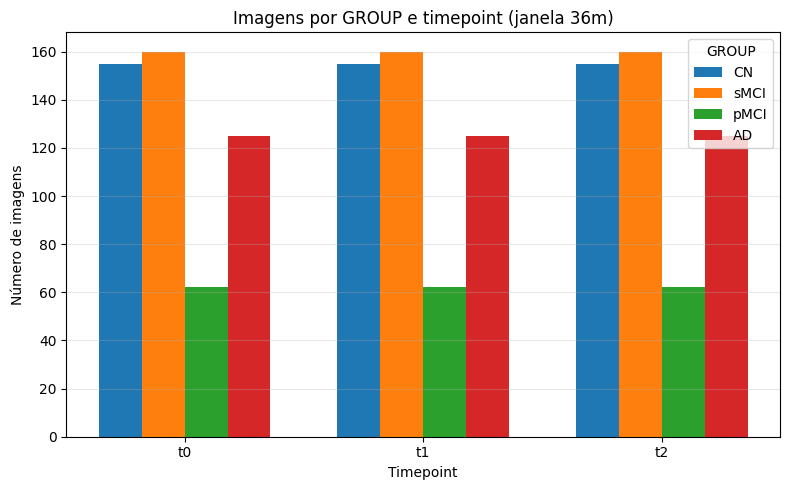

In [17]:
import matplotlib.pyplot as plt

plot_df = img_por_timepoint.reindex(TARGET_GROUPS)
x = plot_df.columns.tolist()
width = 0.18
groups = plot_df.index.tolist()
offsets = [(i - (len(groups) - 1) / 2) * width for i in range(len(groups))]

fig, ax = plt.subplots(figsize=(8, 5))
for offset, group in zip(offsets, groups):
    ax.bar(
        [i + offset for i in range(len(x))],
        plot_df.loc[group].values,
        width=width,
        label=group,
    )

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x)
ax.set_xlabel("Timepoint")
ax.set_ylabel("Número de imagens")
ax.set_title(f"Imagens por GROUP e timepoint (janela {WINDOW_MONTHS}m)")
ax.legend(title="GROUP")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [18]:
CLINICAL_VARS = {
    "AGE": "Age (years)",
    "MMSE_SCORE": "MMSE",
    "ADAS_SCORE": "ADAS",
    "FAQ_SCORE": "FAQ",
}

SLOT_SUFFIX = {"t0": "_t0", "t1": "_t1", "t2": "_t2"}


def mean_std(series: pd.Series) -> str:
    m = series.mean()
    s = series.std()
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.2f} ± —"
    return f"{m:.2f} ± {s:.2f}"


def gender_m_f(series: pd.Series) -> str:
    return f"{(series == 'M').sum()}/{(series == 'F').sum()}"


row_labels = [
    f"{group}{SLOT_SUFFIX[slot]}"
    for group in TARGET_GROUPS
    for slot in SLOT_LABELS
]

col_order = [
    "Sample size",
    "Gender (male/female)",
    *CLINICAL_VARS.values(),
]

table_data = {}

for group in TARGET_GROUPS:
    for slot in SLOT_LABELS:
        row = f"{group}{SLOT_SUFFIX[slot]}"
        sub = longitudinal[
            (longitudinal["GROUP"] == group) & (longitudinal["slot"] == slot)
        ]

        table_data[row] = {
            "Sample size": len(sub),
            "Gender (male/female)": gender_m_f(sub["SEX"]),
        }
        for var, label in CLINICAL_VARS.items():
            table_data[row][label] = mean_std(sub[var])

tabela_caracteristicas = (
    pd.DataFrame(table_data)
    .T
    .reindex(index=row_labels)
    .reindex(columns=col_order)
)

print("Características por GROUP e timepoint (mean ± SD):")
display(tabela_caracteristicas)

print("\nNota: dados representados como média ± DP (SD).")


Características por GROUP e timepoint (mean ± SD):


,Sample size,Gender (male/female),Age (years),MMSE,ADAS,FAQ
CN_t0,155,76/79,76.21 ± 5.17,29.20 ± 0.99,5.76 ± 2.74,0.11 ± 0.43
CN_t1,155,76/79,76.66 ± 5.21,29.16 ± 0.94,5.92 ± 2.74,0.14 ± 0.45
CN_t2,155,76/79,77.21 ± 5.21,28.90 ± 2.65,5.62 ± 2.80,0.13 ± 0.67
sMCI_t0,160,103/57,74.96 ± 7.18,27.22 ± 1.74,10.61 ± 4.11,2.61 ± 3.52
sMCI_t1,160,103/57,75.44 ± 7.11,27.09 ± 2.16,10.63 ± 3.95,3.17 ± 3.85
sMCI_t2,160,103/57,75.92 ± 7.21,27.19 ± 2.31,10.58 ± 4.46,3.70 ± 4.25
pMCI_t0,62,37/25,75.32 ± 7.61,25.60 ± 2.06,13.43 ± 3.92,6.32 ± 4.75
pMCI_t1,62,37/25,75.74 ± 7.66,25.06 ± 2.31,14.78 ± 4.94,6.98 ± 5.02
pMCI_t2,62,37/25,76.08 ± 7.66,24.98 ± 2.24,15.60 ± 4.70,7.85 ± 5.09
AD_t0,125,62/63,75.66 ± 7.77,22.25 ± 3.41,20.72 ± 7.54,15.06 ± 7.50



Nota: dados representados como média ± DP (SD).


# Timepoints 36m completo (pausado)

# Imagens faltantes regions

In [ ]:
# import ants
# import antspynet
# import numpy as np

# ID = "I58423"
# RAW = f"/mnt/databases/mri/adni/raw_data/{ID}.nii.gz"
# OUT_NATIVE = f"images/reregions/{ID}_regions.nii.gz"

# # def audit_labels(seg, tag):
# #     arr = seg.numpy()
# #     for lab in (5, 26, 44, 58, 17, 53):
# #         print(f"  [{tag}] label {lab}: {int((arr == lab).sum())}")

# # raw = ants.image_read(RAW)
# # assert raw.dimension == 4, f"esperado 4D, got {raw.dimension}D"

# best = None
# best_score = -1

# for idx in (0, 1):
#     img3d = ants.slice_image(raw, axis=3, idx=idx)

#     dkt = antspynet.desikan_killiany_tourville_labeling(
#         img3d,
#         do_preprocessing=True,
#         do_lobar_parcellation=False,   # igual readme coorte
#         verbose=True,
#     )
#     seg = dkt["segmentation_image"] if isinstance(dkt, dict) else dkt

#     print(f"\n=== frame idx={idx} ===")
#     # audit_labels(seg, f"idx={idx}")

#     score = sum(int((seg.numpy() == lab).sum()) for lab in (5, 26, 44, 58))
#     if score > best_score:
#         best_score = score
#         best = (idx, seg)

# idx_best, seg_best = best
# print(f"\nMelhor frame: idx={idx_best}, score labels-alvo={best_score}")

# ants.image_write(seg_best, OUT_NATIVE)
# print(f"Salvo: {OUT_NATIVE}")

AttributeError: 'DataFrame' object has no attribute 'has_components'